Notebook 02: Exploratory Data Analysis

Objective: This notebook explores patterns in the cleaned video game sales dataset. The analysis focuses on sales distributions, release trends, genre performance, platform performance, publisher performance, and regional market differences.

The purpose of this stage is to identify meaningful patterns and refine the questions that will be investigated in later statistical and machine-learning notebooks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
processed_file_path = Path("../data/processed/video_game_sales_cleaned.csv")

df = pd.read_csv(processed_file_path)

df.head()

,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.501450,0.350737,0.045564,0.102248,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.722664,0.088966,0.169235,0.019135,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.442367,0.359475,0.105777,0.092381,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.477273,0.333636,0.099394,0.089697,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.359146,0.283301,0.325685,0.031867,North America


In [4]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset shape: (16287, 19)

Data types:
name                        str
platform                    str
year                      int64
genre                       str
publisher                   str
na_sales                float64
eu_sales                float64
jp_sales                float64
other_sales             float64
global_sales            float64
regional_sales_total    float64
decade                      str
sales_tier                  str
is_high_seller            int64
na_sales_share          float64
eu_sales_share          float64
jp_sales_share          float64
other_sales_share       float64
dominant_region             str
dtype: object


In [5]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


How are global video game sales distributed

In [6]:
df["global_sales"].describe()

count    16287.000000
mean         0.541022
std          1.567520
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         82.740000
Name: global_sales, dtype: float64

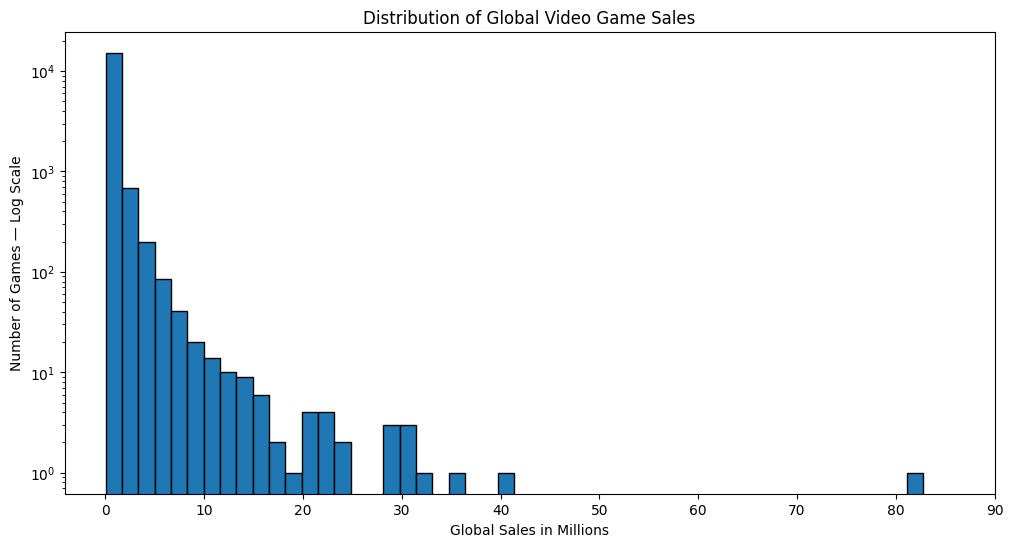

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    df["global_sales"],
    bins=50,
    edgecolor="black"
)

ax.set_yscale("log")

ax.set_title("Distribution of Global Video Game Sales")
ax.set_xlabel("Global Sales in Millions")
ax.set_ylabel("Number of Games — Log Scale")

ax.set_xticks(range(0, 91, 10))

plt.show()

Interpretation

Global video game sales are strongly right-skewed. Most games sold relatively few copies, while progressively fewer games reached higher sales levels. The logarithmic y-axis makes the rare high-selling titles visible without removing them from the dataset. Only a small number of games sold more than 20 million copies, and one extreme title exceeded 80 million copies.

How many games fall into each sales-performance category?

In [8]:
sales_tier_order = [
    "low",
    "medium",
    "high",
    "blockbuster"
]

sales_tier_counts = (
    df["sales_tier"]
    .value_counts()
    .reindex(sales_tier_order)
)

sales_tier_counts

sales_tier
low            12327
medium          1902
high            1852
blockbuster      206
Name: count, dtype: int64

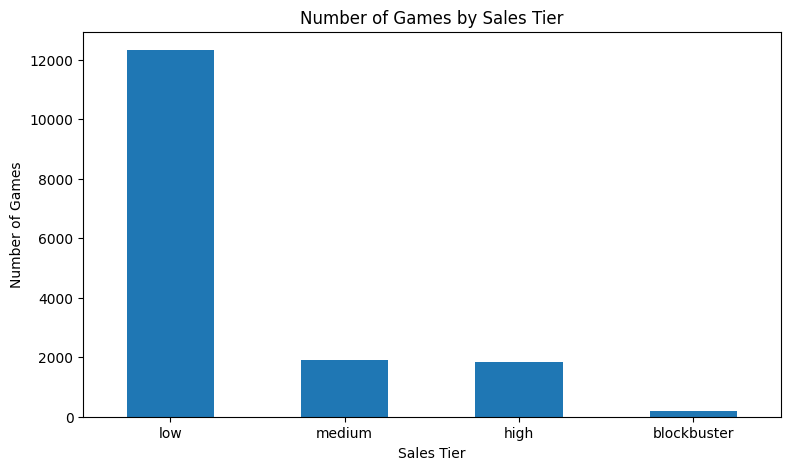

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

sales_tier_counts.plot(kind="bar", ax=ax)

ax.set_title("Number of Games by Sales Tier")
ax.set_xlabel("Sales Tier")
ax.set_ylabel("Number of Games")
ax.tick_params(axis="x", rotation=0)

plt.show()

In [10]:
sales_tier_percentages = (
    df["sales_tier"]
    .value_counts(normalize=True)
    .reindex(sales_tier_order)
    .mul(100)
    .round(2)
)

sales_tier_percentages

sales_tier
low            75.69
medium         11.68
high           11.37
blockbuster     1.26
Name: proportion, dtype: float64

Interpretation

The sales-tier distribution is highly uneven. Approximately **75.69%** of games fall into the low sales tier, compared with **11.68%** in the medium tier, **11.37%** in the high tier, and only **1.26%** in the blockbuster tier.

This shows that major commercial success is relatively uncommon, while most games generate comparatively low global sales.

This imbalance is important for the later `is_high_seller` classification task. Model performance should therefore be evaluated using precision, recall, F1-score, and a confusion matrix rather than accuracy alone.

How did the number of video game releases change over time?

In [11]:
games_by_year = (
    df.groupby("year")
    .size()
    .reset_index(name="game_count")
)

games_by_year.head()

,year,game_count
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14


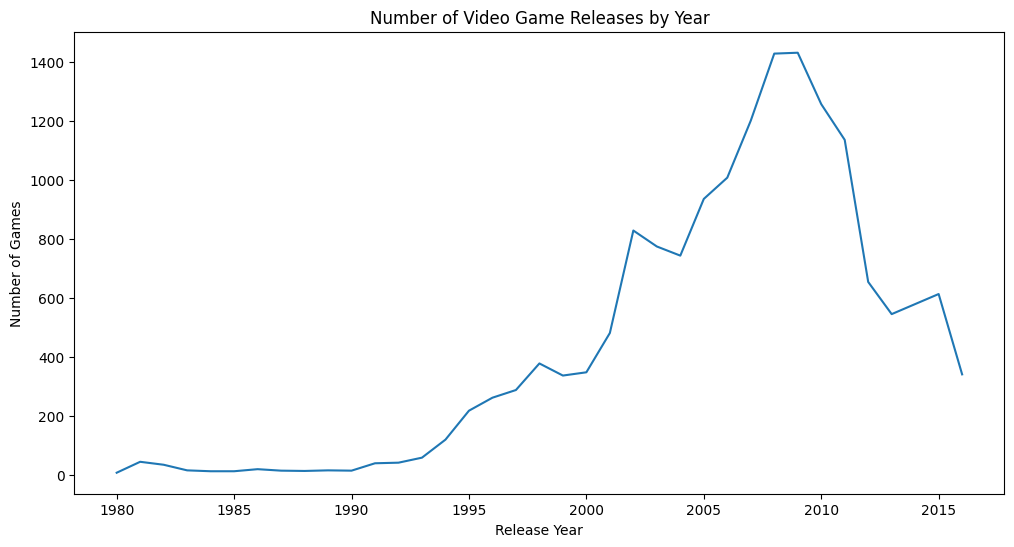

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    games_by_year["year"],
    games_by_year["game_count"]
)

ax.set_title("Number of Video Game Releases by Year")
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Games")

plt.show()

In [13]:
games_by_decade = (
    df.groupby("decade")
    .size()
    .reset_index(name="game_count")
)

games_by_decade

,decade,game_count
0,1980s,205
1,1990s,1769
2,2000s,9183
3,2010s,5130


Interpretation

The number of video game releases remained relatively low throughout the 1980s and early 1990s. Releases began increasing more noticeably during the mid-to-late 1990s and grew rapidly throughout the 2000s.

The number of releases reached its highest level around 2008–2009, with more than 1,400 games released per year. After this peak, the number of recorded releases declined sharply.

The decline after 2011 should be interpreted cautiously because the dataset ends in 2016 and may not contain complete coverage for the most recent years. Therefore, the later drop may reflect both a real market change and limitations in the dataset.

How Did Video Game Sales Change over Time?

In [14]:
yearly_sales_summary = (
    df.groupby("year")
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median")
    )
    .reset_index()
)

yearly_sales_summary.head()

,year,game_count,total_global_sales,average_global_sales,median_global_sales
0,1980,9,11.38,1.264444,0.770
1,1981,46,35.77,0.777609,0.465
2,1982,36,28.86,0.801667,0.540
3,1983,17,16.79,0.987647,0.770
4,1984,14,50.36,3.597143,1.485


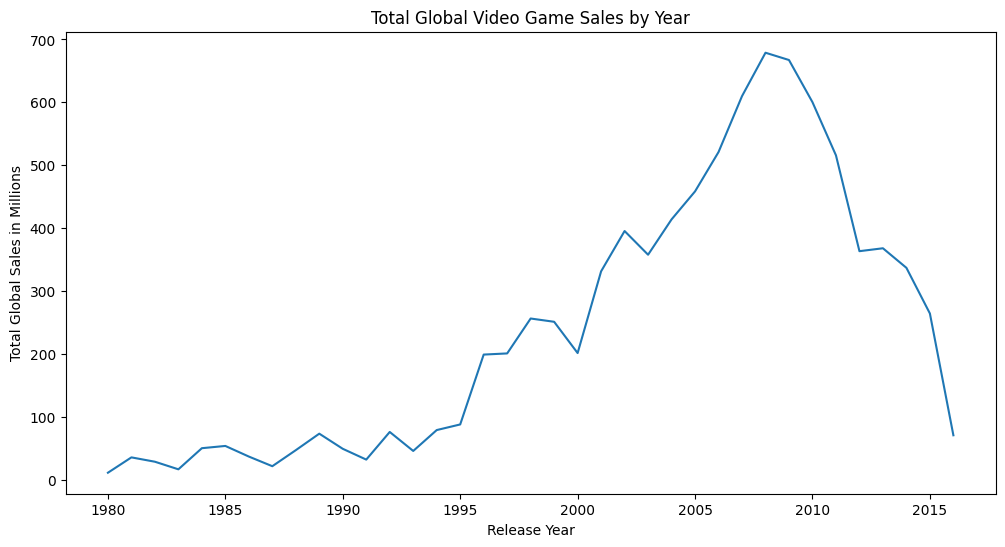

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly_sales_summary["year"],
    yearly_sales_summary["total_global_sales"]
)

ax.set_title("Total Global Video Game Sales by Year")
ax.set_xlabel("Release Year")
ax.set_ylabel("Total Global Sales in Millions")

plt.show()

Interpretation

Total global video game sales remained relatively low throughout the 1980s and early 1990s before increasing more rapidly during the late 1990s and 2000s.

Sales reached their highest level around 2008, at approximately 680 million units, before declining in the following years. This overall pattern is similar to the trend in the number of games released, suggesting that years with more releases also tended to generate higher total sales.

However, total sales alone do not show how well the typical game performed because years with more releases naturally have more opportunities to accumulate sales. For this reason, average and median sales per game should also be examined.

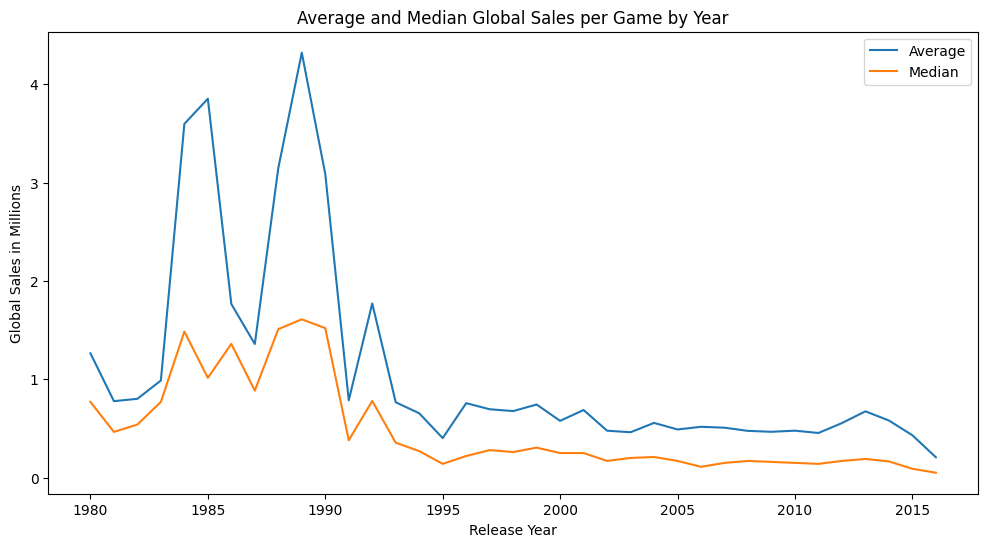

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly_sales_summary["year"],
    yearly_sales_summary["average_global_sales"],
    label="Average"
)

ax.plot(
    yearly_sales_summary["year"],
    yearly_sales_summary["median_global_sales"],
    label="Median"
)

ax.set_title("Average and Median Global Sales per Game by Year")
ax.set_xlabel("Release Year")
ax.set_ylabel("Global Sales in Millions")
ax.legend()

plt.show()

Interpretation

Average global sales were consistently higher than median global sales, indicating that a relatively small number of highly successful games pulled the yearly averages upward.

The gap was especially large during parts of the 1980s and early 1990s. These years also contained fewer releases, so individual blockbuster titles could have had a stronger influence on the yearly mean.

From the mid-1990s onward, both measures became lower and more stable. Although the industry released more games and generated higher total sales during much of the 2000s, the typical individual title continued to record relatively modest sales.

The median is a better measure of typical game performance, while the mean reflects the influence of unusually successful releases.

This section (below) compares genres using game count, total sales, typical sales performance, and the proportion of titles that became high sellers. Total sales alone may favour genres with more releases, so average, median, and high-seller rate are also considered.

In [17]:
genre_summary = (
    df.groupby("genre")
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median"),
        high_seller_rate=("is_high_seller", "mean")
    )
    .reset_index()
)

genre_summary["high_seller_percentage"] = (
    genre_summary["high_seller_rate"] * 100
)

genre_summary

,genre,game_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate,high_seller_percentage
0,Action,3250,1722.83,0.530102,0.190,0.128923,12.892308
1,Adventure,1274,234.59,0.184137,0.060,0.031397,3.139717
2,Fighting,836,444.05,0.531160,0.210,0.147129,14.712919
3,Misc,1686,789.87,0.468488,0.160,0.099644,9.964413
4,Platform,875,829.13,0.947577,0.280,0.221714,22.171429
5,Puzzle,570,242.21,0.424930,0.105,0.098246,9.824561
6,Racing,1225,726.76,0.593273,0.190,0.147755,14.775510
7,Role-Playing,1468,923.79,0.629285,0.190,0.138283,13.828338
8,Shooter,1282,1026.20,0.800468,0.230,0.194228,19.422777
9,Simulation,847,389.69,0.460083,0.160,0.109799,10.979929


Number of games by genre

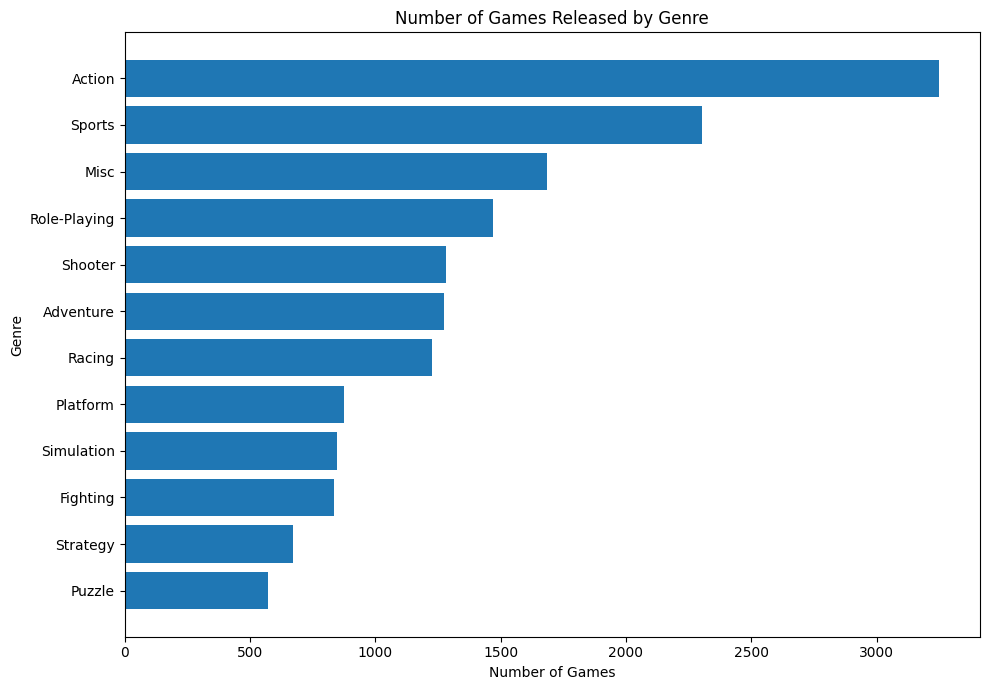

In [18]:
genre_game_count = genre_summary.sort_values(
    "game_count",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    genre_game_count["genre"],
    genre_game_count["game_count"]
)

ax.set_title("Number of Games Released by Genre")
ax.set_xlabel("Number of Games")
ax.set_ylabel("Genre")

plt.tight_layout()
plt.show()

Interpretation

Action has the largest release volume, with 3,250 games, followed by Sports at 2,304 and Misc at 1,686. Puzzle is the smallest category at 570 games, with Strategy next at 670, so the genre counts are highly uneven.

Because later sales totals are partly shaped by how many titles each genre contains, Action and Sports have a structural volume advantage. Smaller genres such as Puzzle and Strategy need average, median, or high-seller-rate comparisons to separate breadth from typical performance.

Total Global Sales by genre

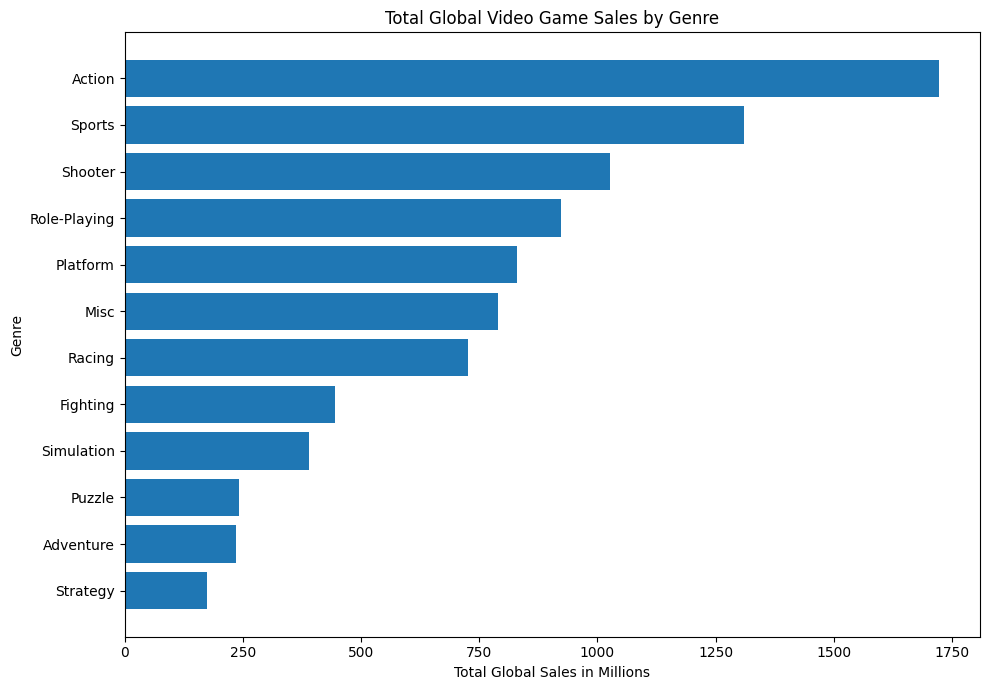

In [19]:
genre_total_sales = genre_summary.sort_values(
    "total_global_sales",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    genre_total_sales["genre"],
    genre_total_sales["total_global_sales"]
)

ax.set_title("Total Global Video Game Sales by Genre")
ax.set_xlabel("Total Global Sales in Millions")
ax.set_ylabel("Genre")

plt.tight_layout()
plt.show()

Interpretation

Action leads total global sales with about 1,722.83 million units, ahead of Sports at 1,309.24 million and Shooter at 1,026.20 million. Strategy is lowest at 173.27 million, with Adventure and Puzzle also low at about 234.59 million and 242.21 million.

The ranking partly reflects category size: Action also has the most games, while Shooter reaches the top three with fewer releases than Sports or Misc. Total sales indicate market scale, but they do not by themselves show that the typical game in a genre sells more.

Average and median sales by genre

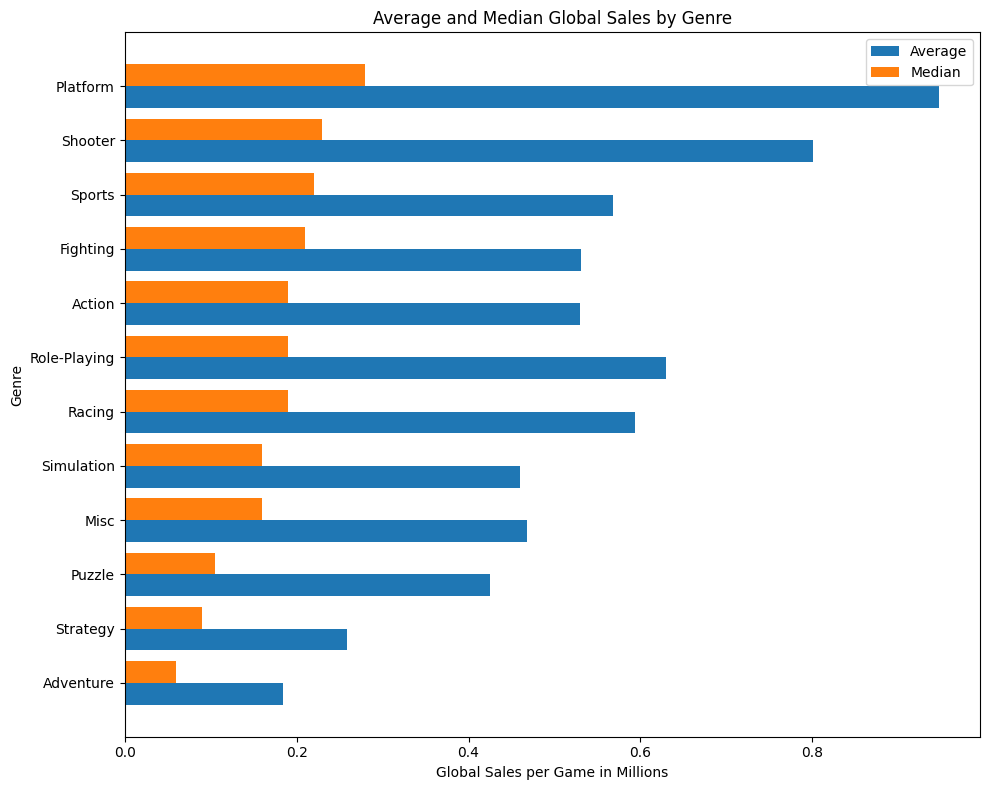

In [20]:
genre_typical_sales = genre_summary.sort_values(
    "median_global_sales",
    ascending=True
)

y_positions = np.arange(len(genre_typical_sales))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    y_positions - bar_height / 2,
    genre_typical_sales["average_global_sales"],
    height=bar_height,
    label="Average"
)

ax.barh(
    y_positions + bar_height / 2,
    genre_typical_sales["median_global_sales"],
    height=bar_height,
    label="Median"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(genre_typical_sales["genre"])

ax.set_title("Average and Median Global Sales by Genre")
ax.set_xlabel("Global Sales per Game in Millions")
ax.set_ylabel("Genre")
ax.legend()

plt.tight_layout()
plt.show()

Interpretation

Platform has the strongest typical performance, with the highest average global sales at about 0.95 million per game and the highest median at 0.28 million. Shooter is also high by average at 0.80 million, while Adventure is lowest by both average and median at about 0.18 million and 0.06 million.

For every genre, the average is above the median, which suggests a right-skewed distribution where a smaller number of high sellers lift the mean. Action has the largest total sales overall, but its median is only about 0.19 million, so its overall lead appears more volume-driven than typical-title-driven.

Next section is about platform performance:
Platform performance is evaluated using release volume, total sales, and typical sales per game. Average and median comparisons are restricted to platforms with at least 50 recorded games to reduce the influence of very small platform samples.

In [21]:
platform_summary = (
    df.groupby("platform")
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median"),
        high_seller_rate=("is_high_seller", "mean")
    )
    .reset_index()
)

platform_summary["high_seller_percentage"] = (
    platform_summary["high_seller_rate"] * 100
)

established_platforms = platform_summary[
    platform_summary["game_count"] >= 50
].copy()

platform_summary.head()

,platform,game_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate,high_seller_percentage
0,2600,116,86.57,0.746293,0.475,0.198276,19.827586
1,3DO,3,0.10,0.033333,0.020,0.000000,0.000000
2,3DS,499,246.27,0.493527,0.130,0.094188,9.418838
3,DC,52,15.97,0.307115,0.135,0.115385,11.538462
4,DS,2130,818.62,0.384329,0.110,0.067606,6.760563


Top 15 platforms by number of games

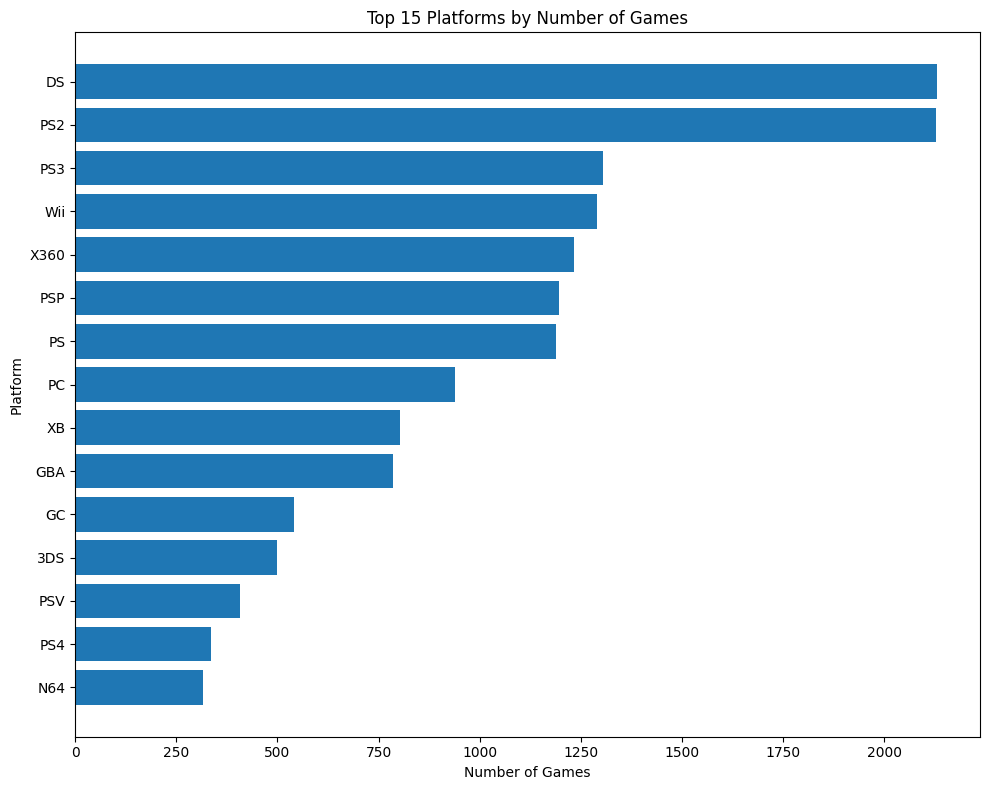

In [22]:
top_platforms_by_games = (
    platform_summary
    .nlargest(15, "game_count")
    .sort_values("game_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_platforms_by_games["platform"],
    top_platforms_by_games["game_count"]
)

ax.set_title("Top 15 Platforms by Number of Games")
ax.set_xlabel("Number of Games")
ax.set_ylabel("Platform")

plt.tight_layout()
plt.show()

Interpretation

DS and PS2 have the largest platform catalogs, at 2,130 and 2,127 games, followed by PS3, Wii, and X360 at roughly 1,300, 1,290, and 1,234 games. N64 is the smallest platform within this top-15 view at 316 games, just below PS4 at 335.

This chart is not filtered by the established-platform threshold; it simply ranks the highest-volume platforms. High release counts may reflect long platform lifespans or large catalogs, so these counts should be compared with sales-per-game charts before interpreting platform strength.

Top 15 platforms by total global sales

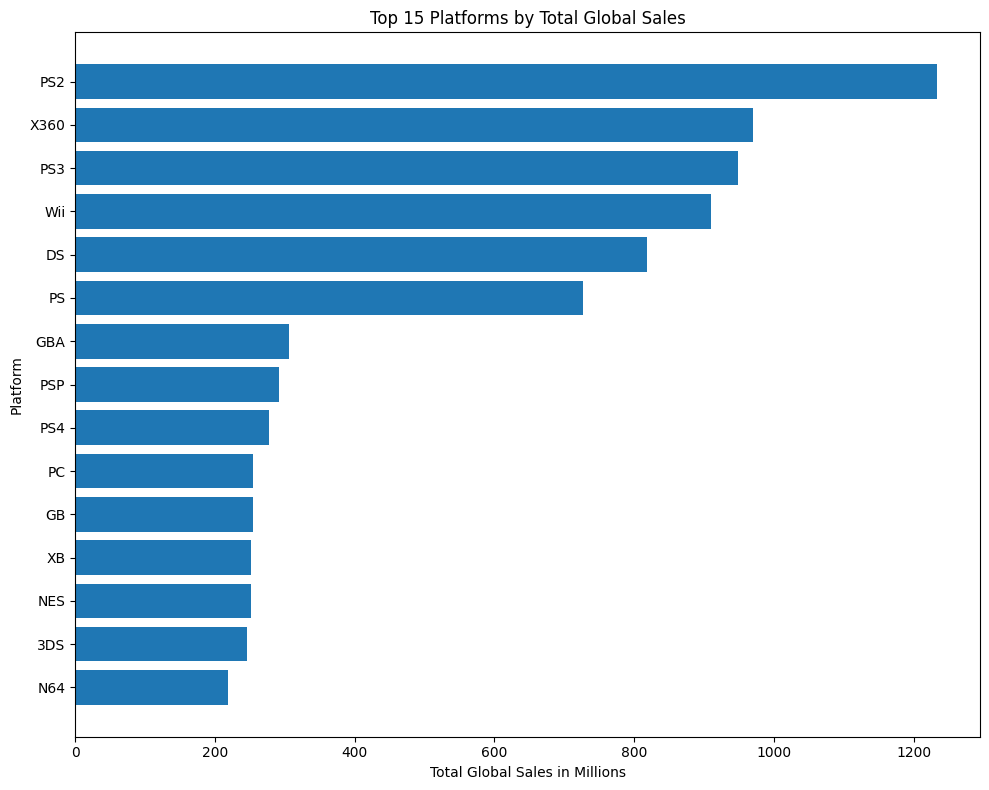

In [23]:
top_platforms_by_sales = (
    platform_summary
    .nlargest(15, "total_global_sales")
    .sort_values("total_global_sales", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_platforms_by_sales["platform"],
    top_platforms_by_sales["total_global_sales"]
)

ax.set_title("Top 15 Platforms by Total Global Sales")
ax.set_xlabel("Total Global Sales in Millions")
ax.set_ylabel("Platform")

plt.tight_layout()
plt.show()

Interpretation

PS2 leads total global sales with about 1,233.46 million units, followed by X360 at 969.60 million, PS3 at 949.35 million, and Wii at 909.81 million. N64 is lowest within the top-15 sales ranking at 218.21 million, though the chart excludes lower-selling platforms outside the top 15.

Total platform sales are strongly influenced by catalog size: PS2 and DS both have more than 2,100 games, while GB and NES appear in the top 15 with fewer than 100 games because their average sales are unusually high. This chart uses all platforms for total sales; the established-platform threshold of at least 50 games is used for per-game comparisons.

Average and median sales for established platforms

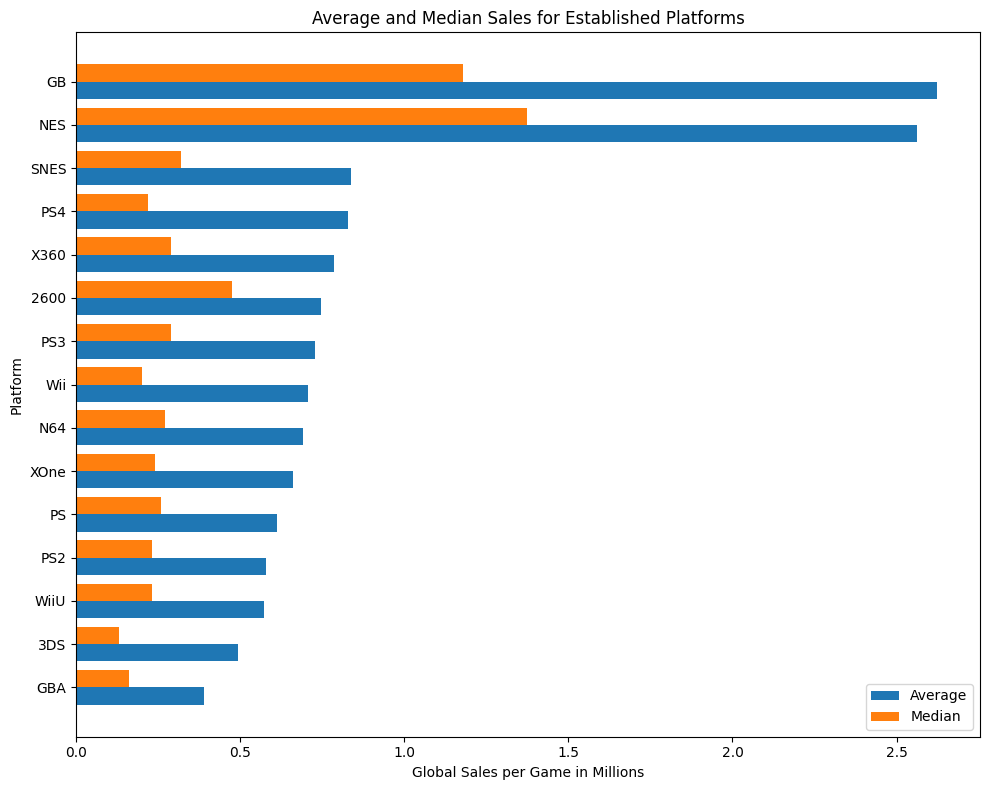

In [24]:
top_established_platforms = (
    established_platforms
    .nlargest(15, "average_global_sales")
    .sort_values("average_global_sales", ascending=True)
)

y_positions = np.arange(len(top_established_platforms))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    y_positions - bar_height / 2,
    top_established_platforms["average_global_sales"],
    height=bar_height,
    label="Average"
)

ax.barh(
    y_positions + bar_height / 2,
    top_established_platforms["median_global_sales"],
    height=bar_height,
    label="Median"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(top_established_platforms["platform"])

ax.set_title(
    "Average and Median Sales for Established Platforms"
)
ax.set_xlabel("Global Sales per Game in Millions")
ax.set_ylabel("Platform")
ax.legend()

plt.tight_layout()
plt.show()

Interpretation

This chart is limited to established platforms with at least 50 recorded games. GB and NES stand far above the rest, with average sales of about 2.62 and 2.56 million per game and medians of 1.18 and 1.38 million, while GBA is the lowest among the displayed top established platforms at about 0.39 average and 0.16 median.

The gap between average and median remains visible for many platforms, indicating that standout hits lift the average. PS4, X360, SNES, and 2600 all have averages near or above 0.75 million, but their lower medians suggest fewer titles achieved those typical high levels.

Next section publisher performance

Publisher performance is compared using release count, total global sales, and typical sales per title. Average and median comparisons include only publishers with at least 20 recorded releases to avoid rankings driven by very small samples.

In [25]:
publisher_summary = (
    df.groupby("publisher")
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median"),
        high_seller_rate=("is_high_seller", "mean")
    )
    .reset_index()
)

publisher_summary["high_seller_percentage"] = (
    publisher_summary["high_seller_rate"] * 100
)

established_publishers = publisher_summary[
    publisher_summary["game_count"] >= 20
].copy()

publisher_summary.head()

,publisher,game_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate,high_seller_percentage
0,10TACLE Studios,3,0.11,0.036667,0.03,0.000000,0.000000
1,1C Company,3,0.10,0.033333,0.04,0.000000,0.000000
2,20th Century Fox Video Games,5,1.94,0.388000,0.34,0.000000,0.000000
3,2D Boy,1,0.04,0.040000,0.04,0.000000,0.000000
4,3DO,36,10.12,0.281111,0.17,0.027778,2.777778


Top 15 publishers by number of games

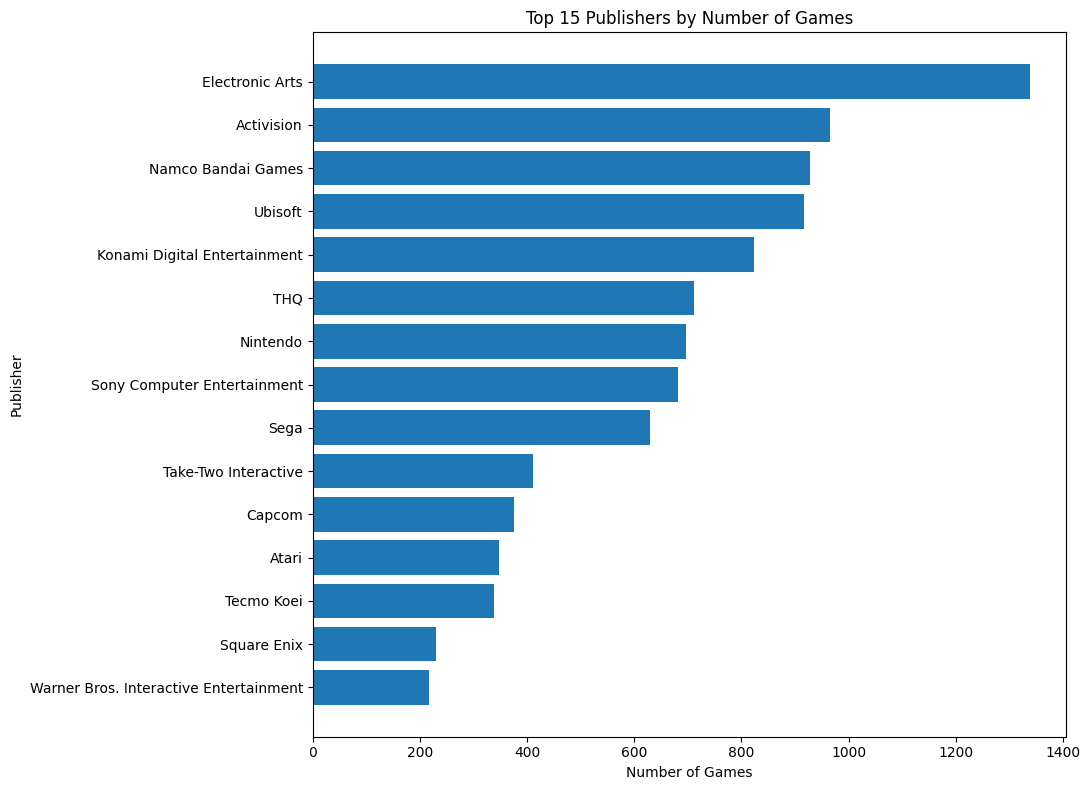

In [26]:
top_publishers_by_games = (
    publisher_summary
    .nlargest(15, "game_count")
    .sort_values("game_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    top_publishers_by_games["publisher"],
    top_publishers_by_games["game_count"]
)

ax.set_title("Top 15 Publishers by Number of Games")
ax.set_xlabel("Number of Games")
ax.set_ylabel("Publisher")

plt.tight_layout()
plt.show()

Interpretation

Electronic Arts has the largest recorded catalog by a wide margin, with 1,339 games, followed by Activision at 966, Namco Bandai Games at 928, and Ubisoft at 917. Warner Bros. Interactive Entertainment is lowest within the top 15 at 217 games, with Square Enix close at 231.

This chart ranks all publishers by release count, without the 20-game threshold used later for average and median comparisons. Large catalogs can make publishers more visible in total sales charts even when their typical game performance is closer to the middle of the field.

Top 15 publishers by total global sales

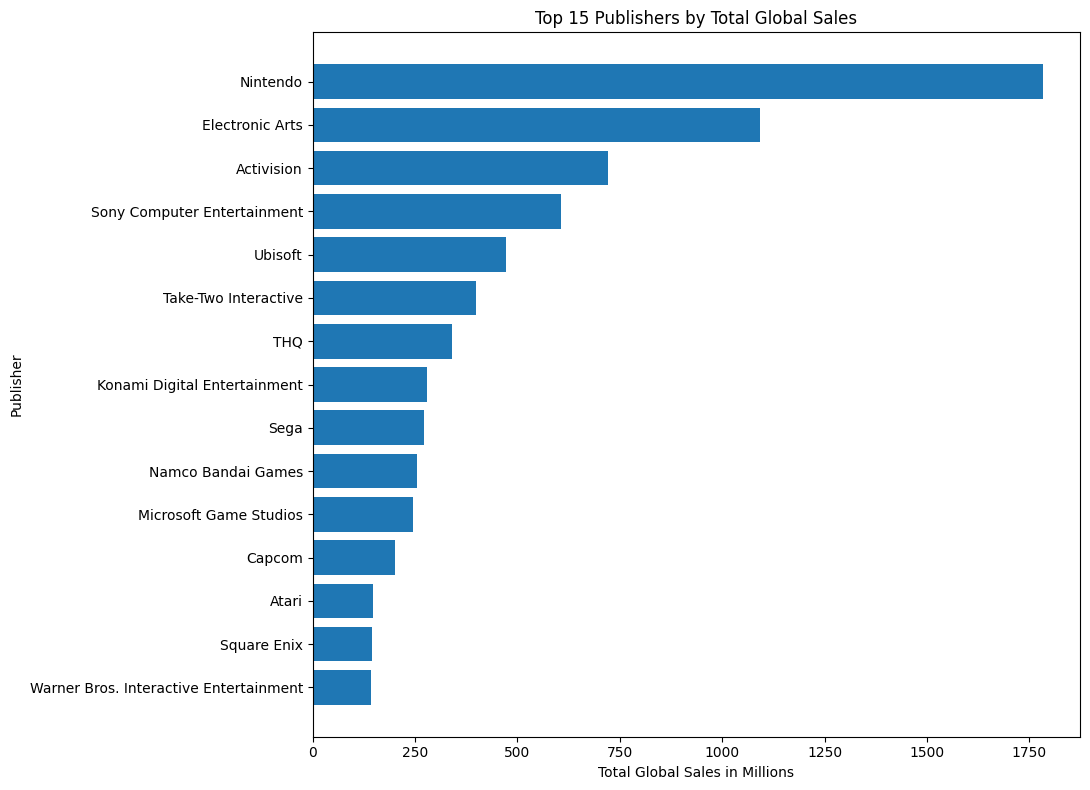

In [27]:
top_publishers_by_sales = (
    publisher_summary
    .nlargest(15, "total_global_sales")
    .sort_values("total_global_sales", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    top_publishers_by_sales["publisher"],
    top_publishers_by_sales["total_global_sales"]
)

ax.set_title("Top 15 Publishers by Total Global Sales")
ax.set_xlabel("Total Global Sales in Millions")
ax.set_ylabel("Publisher")

plt.tight_layout()
plt.show()

Interpretation

Nintendo dominates total global sales with about 1,784.43 million units, well ahead of Electronic Arts at 1,093.39 million and Activision at 721.41 million. Warner Bros. Interactive Entertainment is the lowest publisher within this top-15 sales view at 142.34 million.

Total sales combine catalog size and hit intensity: Nintendo has fewer games than Electronic Arts but much higher average and median sales, while publishers such as Ubisoft and Namco Bandai Games rely more on very large catalogs. This chart uses all publishers; the 20-release threshold is more relevant when interpreting per-game metrics.

Average and median sales for established publishers

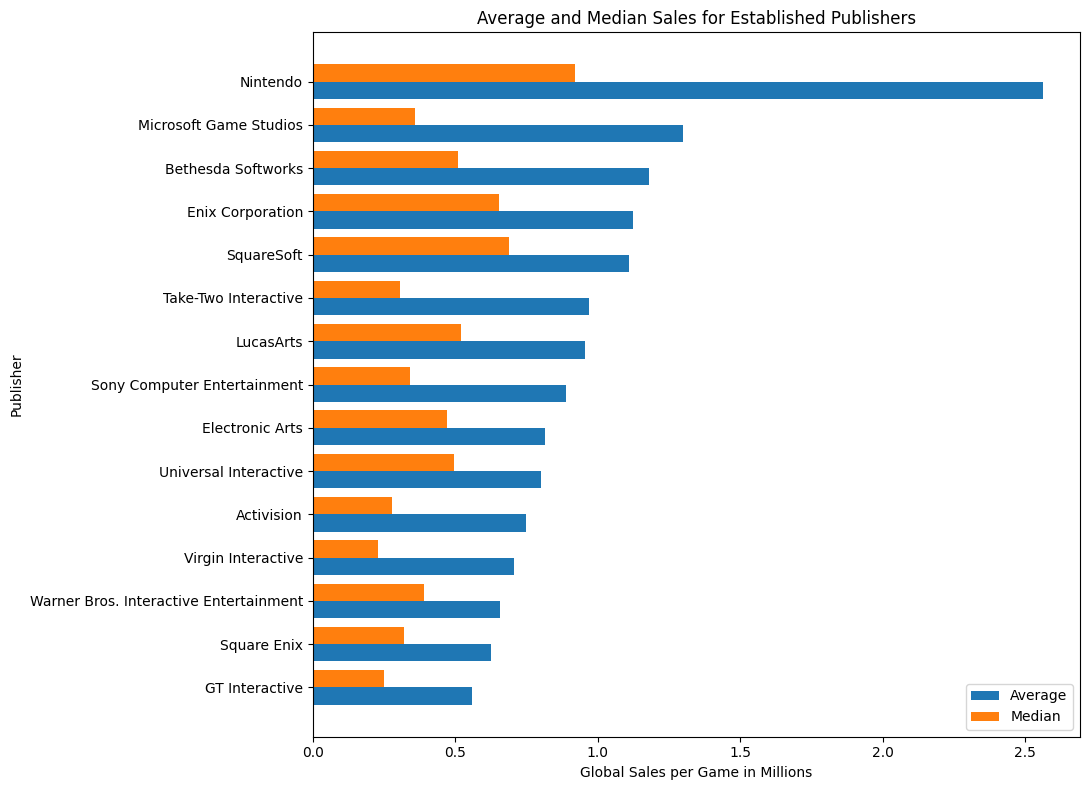

In [28]:
top_established_publishers = (
    established_publishers
    .nlargest(15, "average_global_sales")
    .sort_values("average_global_sales", ascending=True)
)

y_positions = np.arange(len(top_established_publishers))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    y_positions - bar_height / 2,
    top_established_publishers["average_global_sales"],
    height=bar_height,
    label="Average"
)

ax.barh(
    y_positions + bar_height / 2,
    top_established_publishers["median_global_sales"],
    height=bar_height,
    label="Median"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(top_established_publishers["publisher"])

ax.set_title(
    "Average and Median Sales for Established Publishers"
)
ax.set_xlabel("Global Sales per Game in Millions")
ax.set_ylabel("Publisher")
ax.legend()

plt.tight_layout()
plt.show()

Interpretation

Among publishers with at least 20 recorded releases, Nintendo is far ahead with average global sales of about 2.56 million per game and a median of 0.92 million. Microsoft Game Studios, Bethesda Softworks, Enix Corporation, and SquareSoft follow by average sales, while GT Interactive is lowest in this top-15 average view at about 0.56 million.

The large average-median gaps for Nintendo, Microsoft Game Studios, Bethesda, and Take-Two suggest that major hits raise their averages above the typical title. The 20-release threshold reduces very small-sample volatility, but publishers near that cutoff, such as Universal Interactive with 22 games and Enix Corporation with 30, should still be read cautiously.

This section is about regional sales differences

This section compares sales across North America, Europe, Japan, and other markets. Overall totals show the relative size of each recorded market, while genre-level regional shares reveal differences in consumer preferences.

Total sales by region

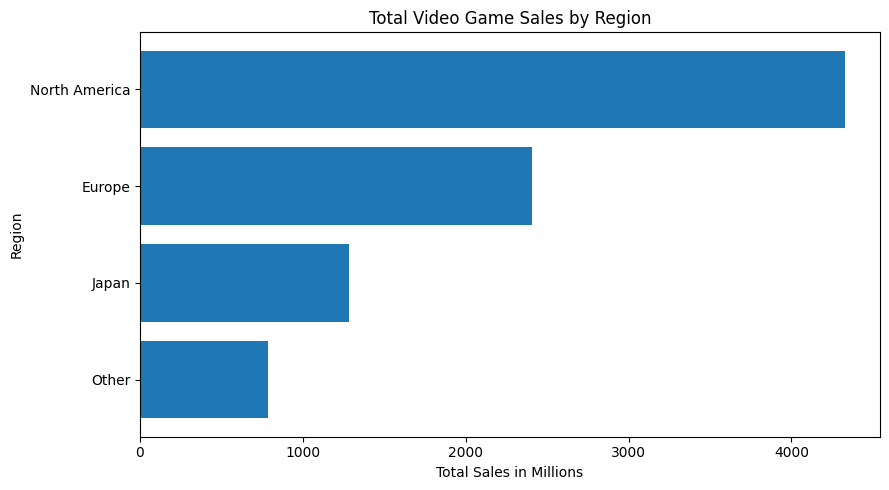

In [29]:
regional_totals = pd.Series({
    "North America": df["na_sales"].sum(),
    "Europe": df["eu_sales"].sum(),
    "Japan": df["jp_sales"].sum(),
    "Other": df["other_sales"].sum()
}).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    regional_totals.index,
    regional_totals.values
)

ax.set_title("Total Video Game Sales by Region")
ax.set_xlabel("Total Sales in Millions")
ax.set_ylabel("Region")

plt.tight_layout()
plt.show()

Interpretation

North America is the largest recorded market, with about 4,327.38 million units, followed by Europe at 2,406.69 million. Japan totals about 1,284.22 million, and Other regions are lowest at 788.89 million.

The gap is substantial: North America accounts for roughly 49% of the combined regional total, while Europe contributes about 27% and Japan about 15%. These totals describe the dataset's recorded sales distribution by region, not the causes of regional demand.

Regional sales by genre

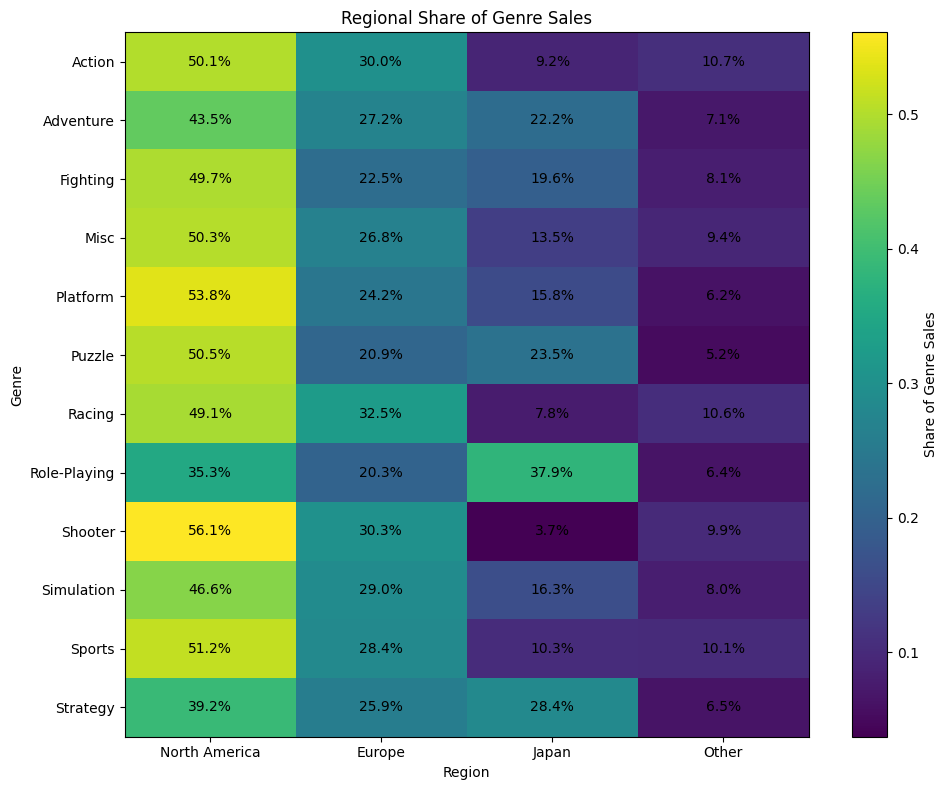

In [30]:
genre_regional_sales = (
    df.groupby("genre")[
        ["na_sales", "eu_sales", "jp_sales", "other_sales"]
    ]
    .sum()
)

genre_regional_shares = genre_regional_sales.div(
    genre_regional_sales.sum(axis=1),
    axis=0
)

genre_regional_shares = genre_regional_shares.rename(
    columns={
        "na_sales": "North America",
        "eu_sales": "Europe",
        "jp_sales": "Japan",
        "other_sales": "Other"
    }
)

## genre_regional_shares

fig, ax = plt.subplots(figsize=(10, 8))

heatmap = ax.imshow(
    genre_regional_shares.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(genre_regional_shares.columns))
)
ax.set_xticklabels(genre_regional_shares.columns)

ax.set_yticks(
    np.arange(len(genre_regional_shares.index))
)
ax.set_yticklabels(genre_regional_shares.index)

ax.set_title("Regional Share of Genre Sales")
ax.set_xlabel("Region")
ax.set_ylabel("Genre")

for row_index in range(
    len(genre_regional_shares.index)
):
    for column_index in range(
        len(genre_regional_shares.columns)
    ):
        value = genre_regional_shares.iloc[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.1%}",
            ha="center",
            va="center"
        )

fig.colorbar(
    heatmap,
    ax=ax,
    label="Share of Genre Sales"
)

plt.tight_layout()
plt.show()

##This normalizes within each genre. Therefore, it compares regional composition rather than allowing the largest genres to dominate the result.

Interpretation

North America is the largest sales share for most genres, especially Shooter at about 56.1% and Platform at 53.8%. Role-Playing is the main exception, with Japan contributing about 37.9% versus North America's 35.3%, and Strategy is also comparatively balanced at 39.2% North America and 28.4% Japan.

Because the heatmap normalizes within each genre, it compares regional composition rather than total genre size. A high percentage in a smaller genre does not mean larger absolute sales than a lower percentage in a much larger genre.

Next section is the dominant market by genre

A game's dominant market is the region in which it recorded its highest sales. The following chart shows how the distribution of dominant markets differs across genres.

Dominant region distribution by genre

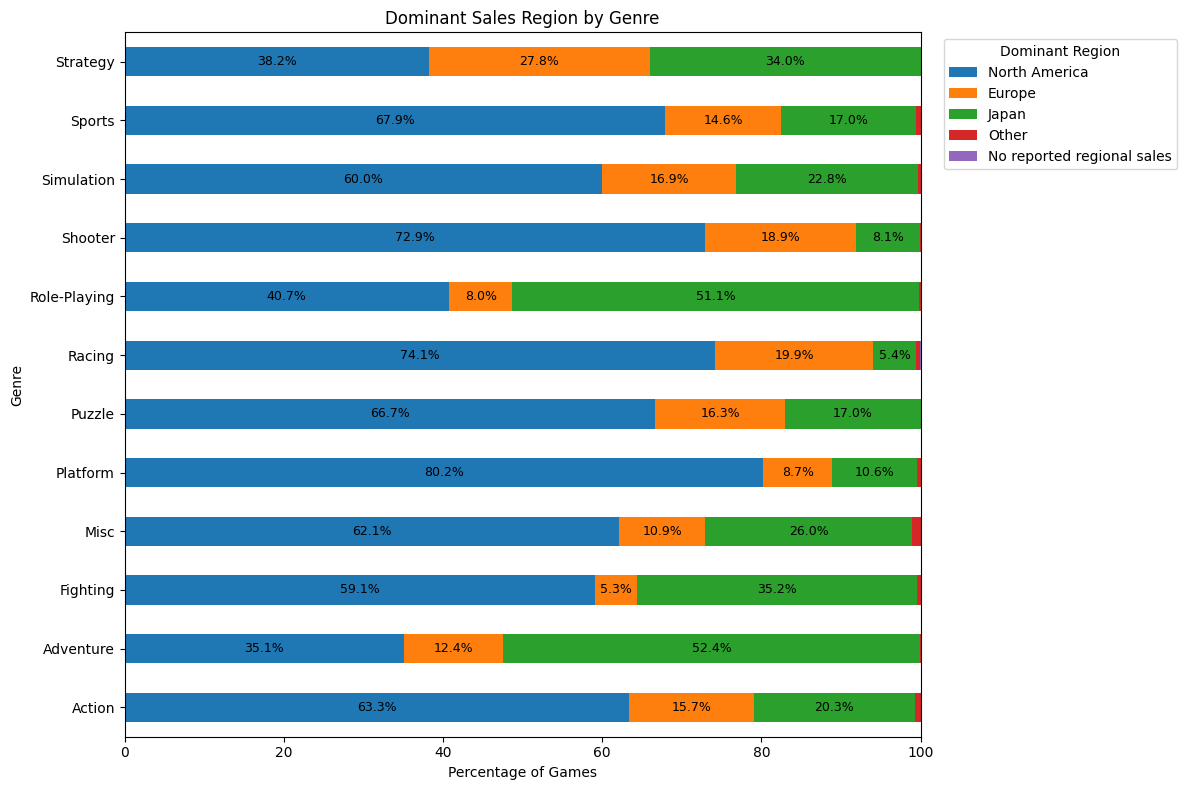

In [31]:
dominant_region_by_genre = pd.crosstab(
    df["genre"],
    df["dominant_region"],
    normalize="index"
).mul(100)

region_order = [
    "North America",
    "Europe",
    "Japan",
    "Other",
    "No reported regional sales"
]

available_regions = [
    region
    for region in region_order
    if region in dominant_region_by_genre.columns
]

dominant_region_by_genre = (
    dominant_region_by_genre[available_regions]
)

fig, ax = plt.subplots(figsize=(12, 8))

dominant_region_by_genre.plot(
    kind="barh",
    stacked=True,
    ax=ax
)

for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 3 else '' for v in container]
    ax.bar_label(
        container, 
        labels=labels, 
        label_type='center', 
        fontsize=9, 
        color='black' 
    )

ax.set_title("Dominant Sales Region by Genre")
ax.set_xlabel("Percentage of Games")
ax.set_ylabel("Genre")
ax.legend(
    title="Dominant Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Interpretation

North America is the dominant sales region for most genres, reaching about 80.2% of Platform games, 74.1% of Racing games, and 72.9% of Shooter games. Japan is the dominant region for a majority of Adventure games at 52.4% and Role-Playing games at 51.1%.

Strategy stands out as the most evenly split genre, with North America at 38.2%, Japan at 34.0%, and Europe at 27.8%. The chart classifies each game by its largest region, so it emphasizes where titles lead rather than how total sales are distributed across regions.

Next section high sller rates

A high-selling game is defined as a title with at least 1 million units in global sales. High-seller rates allow categories of different sizes to be compared more fairly than raw high-seller counts.

High seller rate by genre

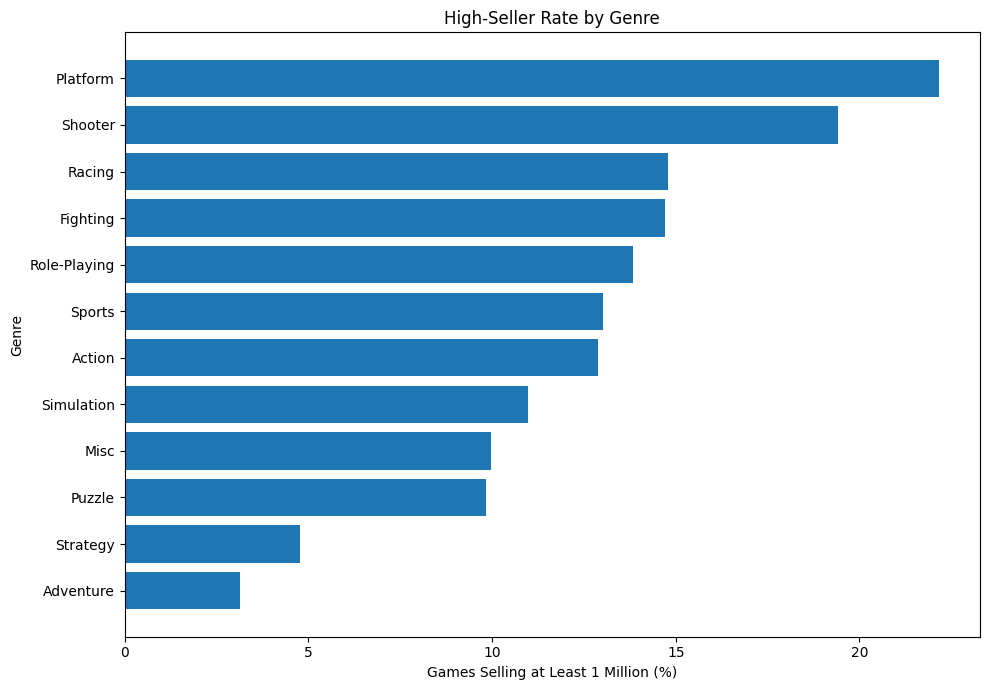

In [32]:
genre_high_seller_rate = (
    df.groupby("genre")["is_high_seller"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    genre_high_seller_rate.index,
    genre_high_seller_rate.values
)

ax.set_title("High-Seller Rate by Genre")
ax.set_xlabel("Games Selling at Least 1 Million (%)")
ax.set_ylabel("Genre")

plt.tight_layout()
plt.show()

Interpretation

Platform has the highest high-seller rate, with about 22.17% of games reaching at least 1 million global sales, followed by Shooter at 19.42%. Adventure is lowest at 3.14%, with Strategy next at 4.78%.

This rate comparison is less affected by raw category size than total sales, but sample sizes still matter: Platform has 875 games and Shooter 1,282, while Puzzle has 570. Action leads total sales overall, yet its high-seller rate is 12.89%, which suggests its dominance is partly driven by release volume.

High seller rate by established platform

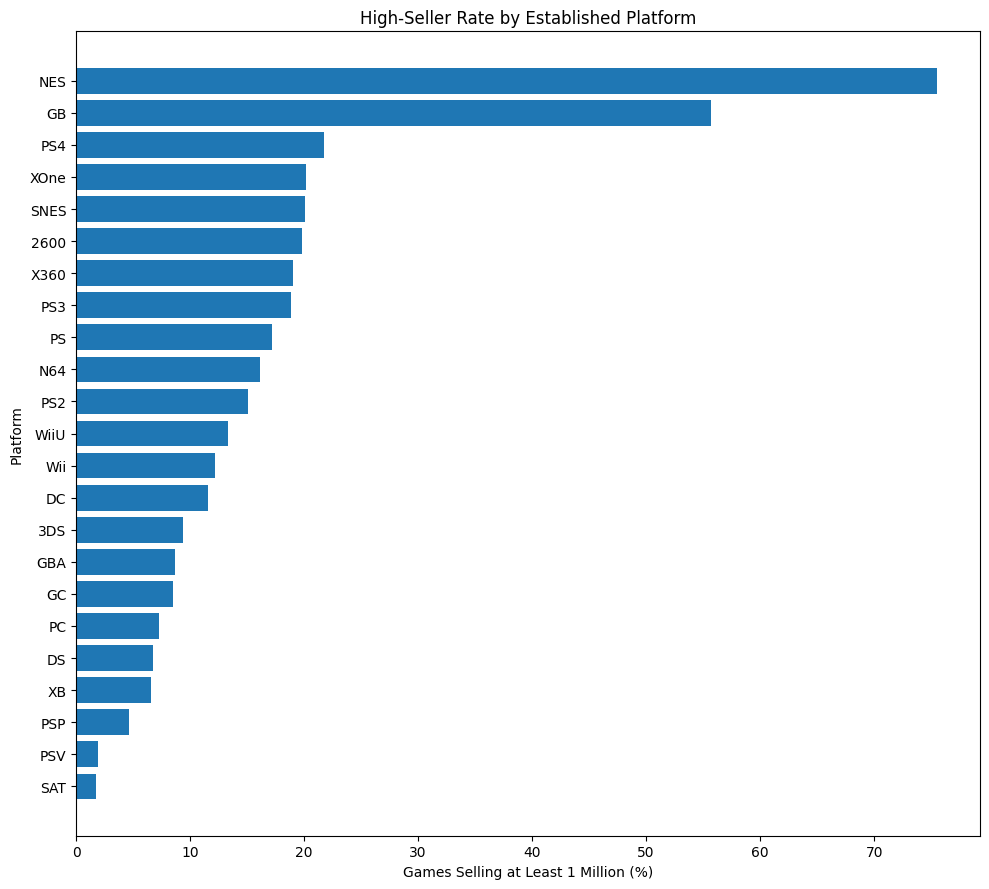

In [33]:
platform_high_seller_rate = (
    established_platforms
    .sort_values(
        "high_seller_percentage",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(
    platform_high_seller_rate["platform"],
    platform_high_seller_rate[
        "high_seller_percentage"
    ]
)

ax.set_title(
    "High-Seller Rate by Established Platform"
)
ax.set_xlabel("Games Selling at Least 1 Million (%)")
ax.set_ylabel("Platform")

plt.tight_layout()
plt.show()

Interpretation

Among established platforms with at least 50 games, NES has the highest high-seller rate at about 75.51%, followed by GB at 55.67%. SAT and PSV are lowest at about 1.73% and 1.96%, with PSP also low at 4.68%.

The threshold helps avoid rankings based on only a handful of games, but NES and GB still have relatively small catalogs just under 100 games each, so their very high rates should be interpreted with that context. More recent high-volume platforms such as PS3, X360, and PS4 cluster around 18.9% to 21.8%.

High seller rate by decade

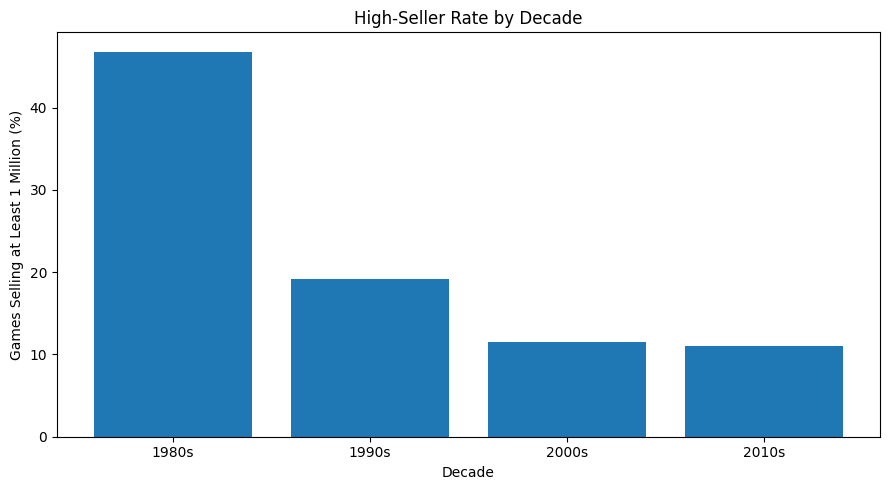

In [34]:
decade_high_seller_summary = (
    df.groupby("decade")
    .agg(
        game_count=("name", "count"),
        high_seller_rate=("is_high_seller", "mean")
    )
    .reset_index()
)

decade_high_seller_summary[
    "high_seller_percentage"
] = (
    decade_high_seller_summary[
        "high_seller_rate"
    ] * 100
)

##decade_high_seller_summary
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    decade_high_seller_summary["decade"],
    decade_high_seller_summary[
        "high_seller_percentage"
    ]
)

ax.set_title("High-Seller Rate by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Games Selling at Least 1 Million (%)")

plt.tight_layout()
plt.show()


Interpretation

The 1980s have the highest high-seller rate by a large margin, with about 46.83% of recorded games reaching at least 1 million global sales. The rate drops to 19.22% in the 1990s and then sits near 11% in both the 2000s and 2010s.

The 1980s also have the smallest sample, with 205 games, compared with 9,183 in the 2000s and 5,130 in the 2010s. The high early rate may reflect the dataset's coverage of commercially notable older titles, so it should be treated as an observed pattern rather than proof that releases in that decade were inherently more successful.

Correlations among numeric sales variables

The correlation matrix measures how strongly regional and global sales variables move together. Correlation describes association, not causation. Because global sales are constructed from regional sales, strong correlations with global sales are expected.

Sales correlation heatmap

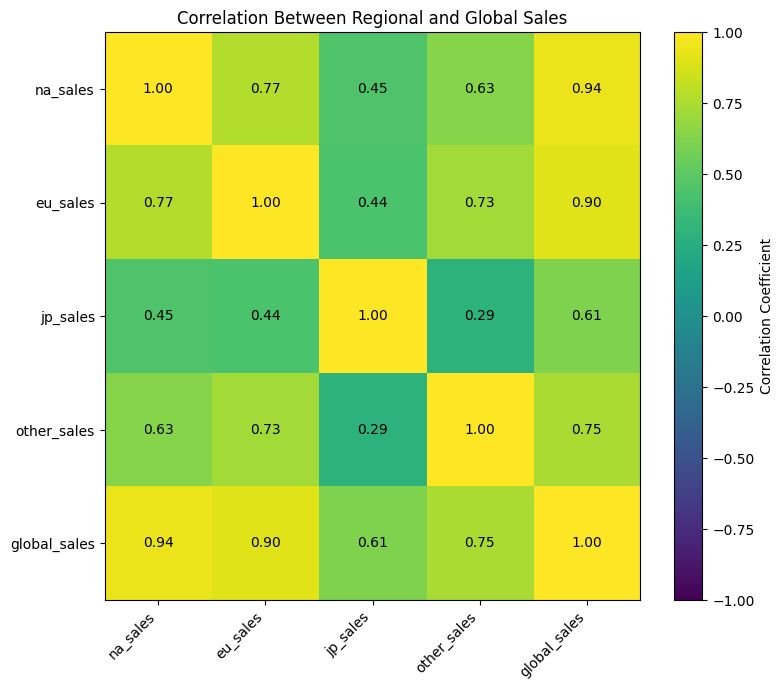

In [35]:
sales_columns = [
    "na_sales",
    "eu_sales",
    "jp_sales",
    "other_sales",
    "global_sales"
]

sales_correlations = df[sales_columns].corr()

##sales_correlations

fig, ax = plt.subplots(figsize=(8, 7))

heatmap = ax.imshow(
    sales_correlations.values,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(sales_correlations.columns))
)
ax.set_xticklabels(
    sales_correlations.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(len(sales_correlations.index))
)
ax.set_yticklabels(
    sales_correlations.index
)

ax.set_title("Correlation Between Regional and Global Sales")

for row_index in range(
    len(sales_correlations.index)
):
    for column_index in range(
        len(sales_correlations.columns)
    ):
        value = sales_correlations.iloc[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    heatmap,
    ax=ax,
    label="Correlation Coefficient"
)

plt.tight_layout()
plt.show()

Interpretation

Global sales are most strongly associated with North America sales at about 0.94 and Europe sales at about 0.90, followed by Other at 0.75 and Japan at 0.61. Among regions, North America and Europe have the strongest pairwise correlation at about 0.77.

These are associations, not causal effects. Because global sales are constructed from the regional sales columns, high correlations with global sales are expected and should be read as a consistency check on how regional markets move together within the dataset.

Release volume versus total sales

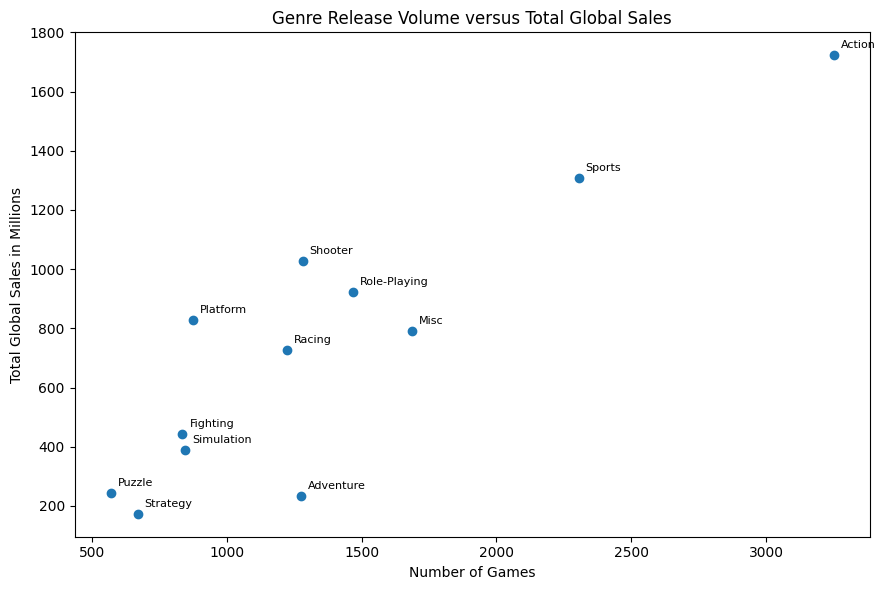

In [36]:
genre_volume_sales = (
    df.groupby("genre")
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    genre_volume_sales["game_count"],
    genre_volume_sales["total_global_sales"]
)

for _, row in genre_volume_sales.iterrows():
    ax.annotate(
        row["genre"],
        (
            row["game_count"],
            row["total_global_sales"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title(
    "Genre Release Volume versus Total Global Sales"
)
ax.set_xlabel("Number of Games")
ax.set_ylabel("Total Global Sales in Millions")

plt.tight_layout()
plt.show()

Interpretation

The scatterplot shows a positive relationship between release volume and total global sales: Action has both the most games at 3,250 and the highest total sales at about 1,722.83 million, while Sports is also high on both dimensions. Strategy is low on both, with 670 games and about 173.27 million in total sales.

There are important deviations from a pure volume story. Shooter has fewer games than Role-Playing, Misc, and Sports but higher total sales than Role-Playing and Misc, while Platform has only 875 games yet reaches about 829.13 million in total sales, indicating stronger sales per game than several larger genres.